<a href="https://colab.research.google.com/github/TsotneDzeria/RML/blob/main/Individual_assignment_1_RML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Individual Assignment 1 - Tsotne Dzeria
*DNSC 6330: Responsible Machine Learning*

GenAI Disclosure: Claude AI was used for code review and to improve the clarity and flow of written responses. All ideas, analysis, and conclusions are entirely my own.

# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Loading dataset

import pandas as pd

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

# Number of rows in dataset
raw_data.shape[0]

7214

In [ ]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons to remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [ ]:
import numpy as np

# Data preprocessing and feature construction

# Defining variable groups
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Selecting relevant columns
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# Applying filtering conditions (same as R workflow)
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Converting datetime variables
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", errors="coerce")

# Converting categorical variables
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# Creating derived categorical features with same reference groups
df["crime_factor"] = df["c_charge_degree"]

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"]
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [c for c in df["race"].cat.categories if c != "Caucasian"]
)

df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"]
)

df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] == "Low", "LowScore", "HighScore"),
    categories=["LowScore", "HighScore"]
)

# Number of rows after preprocessing
df.shape[0]

6172

In [ ]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   category      
 2   race                     6172 non-null   category      
 3   age_cat                  6172 non-null   category      
 4   score_text               6172 non-null   category      
 5   sex                      6172 non-null   category      
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   category      
 10  two_year_recid           6172 non-null   category      
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [ ]:
# -------------------------------
# Analyze relationship between length of stay and COMPAS score
# -------------------------------

# Ensure datetime conversion is correct
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"], errors="coerce")
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"], errors="coerce")

# Calculate length of stay (in days)
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

# Compute correlation
correlation = df["length_of_stay"].corr(df["decile_score"])
correlation

np.float64(0.20747808478031807)

The correlation between length of stay and decile score is positive, indicating that individuals with higher COMPAS risk scores tend to have slightly longer jail stays. However, the strength of the correlation is relatively weak, suggesting that while there is a relationship, COMPAS scores alone do not strongly determine the length of incarceration.

After filtering we have the following demographic breakdown:

In [ ]:
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [ ]:
df["race"].value_counts().sort_index()

,count
race,
African-American,3175
Asian,31
Caucasian,2103
Hispanic,509
Native American,11
Other,343


In [ ]:
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [ ]:
df["score_text"].value_counts().sort_index()

,count
score_text,
High,1144
Low,3421
Medium,1607


In [ ]:
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [ ]:
df["sex"].value_counts().sort_index()

,count
sex,
Female,1175
Male,4997


In [ ]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [ ]:
df[df["two_year_recid"] == 1].shape[0]

2809

In [ ]:
df[df["two_year_recid"] == 1].shape[0] / df.shape[0] * 100

45.51198963058976

Approximately 45.5% of individuals in the dataset recidivated within two years. This provides a baseline understanding of the prevalence of reoffending in the filtered sample and is important for evaluating the predictive performance of the COMPAS scores in later analysis.

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

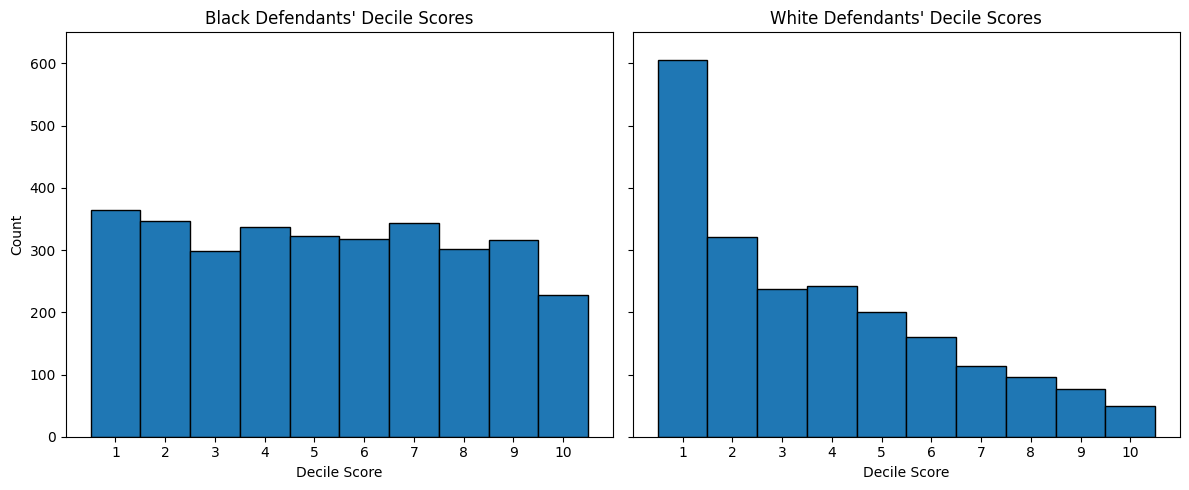

In [ ]:
# -------------------------------
# Compare decile score distributions by race
# -------------------------------

import matplotlib.pyplot as plt
import numpy as np

black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Black defendants
axes[0].hist(black_df["decile_score"], bins=np.arange(1, 12) - 0.5, edgecolor="black")
axes[0].set_title("Black Defendants' Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_xticks(range(1, 11))
axes[0].set_ylim(0, 650)

# White defendants
axes[1].hist(white_df["decile_score"], bins=np.arange(1, 12) - 0.5, edgecolor="black")
axes[1].set_title("White Defendants' Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_xticks(range(1, 11))
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

The distributions show clear differences in COMPAS decile scores between Black and White defendants. Black defendants appear more frequently in higher decile score categories, while White defendants are more concentrated in lower score ranges. This suggests a potential disparity in how risk scores are assigned across racial groups, which motivates further analysis in the modeling section.

In [ ]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [ ]:
# -------------------------------
# Logistic regression model (COMPAS score prediction)
# -------------------------------

# Create binary target: 1 = HighScore, 0 = LowScore
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

import statsmodels.formula.api as smf

model_glm = smf.logit(
    "score_binary ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df
).fit()

model_glm.summary()

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        22:47:18   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.5255      0.079    -19.430      0.000      -1.679      -1.372
gender_factor[T.Female]             0.2213      0.080      2.783      0.005       0.065       0.377
age_factor[T.Greater than 45]      -1.3556      0.099    -13.682      0.000      -1.550      -1.161
age_factor[T.Less than 25]          1.3084      0.076     17.232      0.000       1.160       1.457
race_factor[T.African-American]     0.4772      0.069      6.881      0.000       0.341       0.613
race_factor[T.Asian]               -0.2544      0.478     -0.532      0.595      -1.192       0.683
race_factor[T.Hispanic]            -0.4284      0.128     -3.344      0.001      -0.680      -0.177
race_factor[T.Native American]      1.3942      0.766      1.820      0.069      -0.107       2.896
race_factor[T.Other]               -0.8263      0.162     -5.098      0.000      -1.144      -0.509
crime_factor[T.M]                  -0.3112      0.067     -4.677      0.000      -0.442      -0.181
two_year_recid[T.1]                 0.6859      0.064     10.713      0.000       0.560       0.811
priors_count                        0.2689      0.011     24.221      0.000       0.247       0.291
===================================================================================================
"""

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [ ]:
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))

np.float64(1.4528408658138932)

Women are 19.4% more likely than men to get a higher score.

In [ ]:
np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))

np.float64(1.1947978508506671)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [ ]:
np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))

np.float64(2.4961202077189455)

In [ ]:
# -------------------------------
# Generate predicted probabilities and classifications
# -------------------------------

# Predicted probabilities
df["pred_prob"] = model_glm.predict(df)

# Convert probabilities into classes (threshold = 0.5)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")
df["pred_class"] = pd.Categorical(df["pred_class"], categories=["No Recid", "Recid"])

In [ ]:
# -------------------------------
# Evaluate model performance (confusion matrix and metrics)
# -------------------------------

# Confusion matrix
overall_cm = pd.crosstab(df["pred_class"], df["two_year_recid"])

print("\n── Overall Confusion Matrix ──────────────────────────\n")
print(overall_cm)

# Extract values
TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]

n = overall_cm.values.sum()

# Metrics
accuracy = (TP + TN) / n
precision = TP / (TP + FP)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────

two_year_recid     0     1
pred_class                
No Recid        2653   945
Recid            710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


The confusion matrix summarizes the model’s predictions compared to actual outcomes. The accuracy measures the overall correctness of the model, while precision indicates how often predicted recidivism is correct. Recall reflects the model’s ability to identify actual recidivists. The false positive rate (FPR) and false negative rate (FNR) provide insight into the types of errors the model makes. These metrics help evaluate not only overall performance but also whether the model may disproportionately misclassify certain groups.

In [ ]:
# -------------------------------
# Evaluate model performance by race
# -------------------------------

df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

race_metrics = (
    df.groupby("race")
      .apply(lambda x: pd.Series({
          "n": len(x),
          "TP": ((x["pred"] == 1) & (x["actual"] == 1)).sum(),
          "TN": ((x["pred"] == 0) & (x["actual"] == 0)).sum(),
          "FP": ((x["pred"] == 1) & (x["actual"] == 0)).sum(),
          "FN": ((x["pred"] == 0) & (x["actual"] == 1)).sum()
      }))
      .reset_index()
)

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False)

print("\n── Confusion Matrix by Race ──────────────────────────\n")
print(race_metrics)


── Confusion Matrix by Race ──────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


Evaluating the model by race makes it possible to examine whether prediction errors are distributed evenly across demographic groups. Comparing metrics such as false positive rate and false negative rate across races is especially important in a fairness analysis, because unequal error rates may indicate that the model disadvantages some groups more than others.

In [ ]:
# -------------------------------
# Compute FPR and FNR disparity relative to Caucasian group
# -------------------------------

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# Get baseline (Caucasian)
baseline_FPR = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
baseline_FNR = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Compute differences
disparity["delta_FPR"] = (disparity["FPR"] - baseline_FPR).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - baseline_FNR).round(3)

print("\n── FPR and FNR Disparity by Race ─────────────────────\n")
print(disparity)


── FPR and FNR Disparity by Race ─────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


The disparity table compares error rates across racial groups relative to Caucasian defendants. Positive values of delta FPR indicate that a group is more likely to be falsely predicted as recidivating compared to the baseline, while negative values indicate fewer such errors. Similarly, differences in FNR show disparities in missed predictions of actual recidivism. These differences highlight potential fairness concerns, as unequal error rates across groups suggest that the model may systematically disadvantage certain populations.